## Thứ tự chạy

1. Thiết lập môi trường.
2. Tính held-out direct-alpha SLME và tạo CSV tham chiếu.
3. `FINAL FAIR COMPARISON`: tính SLME hai route, xuất bảng chung.
4. Vẽ Route 2, Route 1 và hình so sánh S5.
5. Chạy paired bootstrap trên bảng chung.
6. Chạy external DFT40 Route 2 (độc lập với held-out).

**Đầu vào có sẵn:** `processed/paired_training/paper_outputs/final_alpha_route_audit/FINAL_alpha_route_comparison_arrays.npz`.
Notebook này không tạo file audit đó và không huấn luyện lại mô hình.


In [2]:
from pathlib import Path
import sys

PROJECT_ROOT = Path(r"D:\TB3")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import utils_tb
import utils_tb.data as DATA

print("utils_tb:", utils_tb.__file__)
print("data.py :", DATA.__file__)

utils_tb: D:\TB3\utils_tb\__init__.py
data.py : D:\TB3\utils_tb\data.py


DIRECT-ALPHA SOURCE
Folder : D:\TB3\processed\paired_training\epsI_alpha_log10_1p_direct_alpha_ssl_init_enhanced_19_24_d005_wd5e5_3seed
Seeds  : [42, 123, 2025]
 - test_predictions_epsI_alpha_log10_1p_direct_alpha_ssl_init_enhanced_19_24_d005_wd5e5_3seed_seed123.npz
 - test_predictions_epsI_alpha_log10_1p_direct_alpha_ssl_init_enhanced_19_24_d005_wd5e5_3seed_seed2025.npz
 - test_predictions_epsI_alpha_log10_1p_direct_alpha_ssl_init_enhanced_19_24_d005_wd5e5_3seed_seed42.npz

ALPHA AUDIT
Shape               : (992, 2001)
Energy range        : 0.000 to 20.000 eV
Reference alpha max : 2.800e+06 cm^-1
Predicted alpha max : 3.198e+06 cm^-1

BAND-GAP AUDIT
Direct-gap range   : 0.136464 to 8.568791 eV
Indirect-gap range : 0.116651 to 8.445386 eV
Optical cutoff     : 0.136464 to 8.568791 eV
Direct-gap fallback: 0

AM1.5G AUDIT
Psolar (200-2500 nm) = 994.140 W/m^2

FINAL SLME / SQ SANITY CHECK
SQ maximum             : 33.799% at Eg = 1.339 eV
Reference SLME range   : 0.000% to 33.766%
Predicted

,route,alpha_target,n_test_samples,n_model_seeds,model_seeds,gap_cutoff,thickness_nm,temperature_K,fr,solar_spectrum,...,reference_SLME_max_percent,predicted_SLME_max_percent,Top10_overlap_count,Top10_overlap_percent,Top20_overlap_count,Top20_overlap_percent,Top50_overlap_count,Top50_overlap_percent,Top100_overlap_count,Top100_overlap_percent
0,Direct-alpha SSL-init GINE -> SLME,log10(1 + alpha_cm^-1),992,3,"42,123,2025",independent direct gap,500.0,300.0,1.0,ASTM G173 AM1.5G,...,33.765528,33.724535,5,50.0,13,65.0,44,88.0,89,89.0


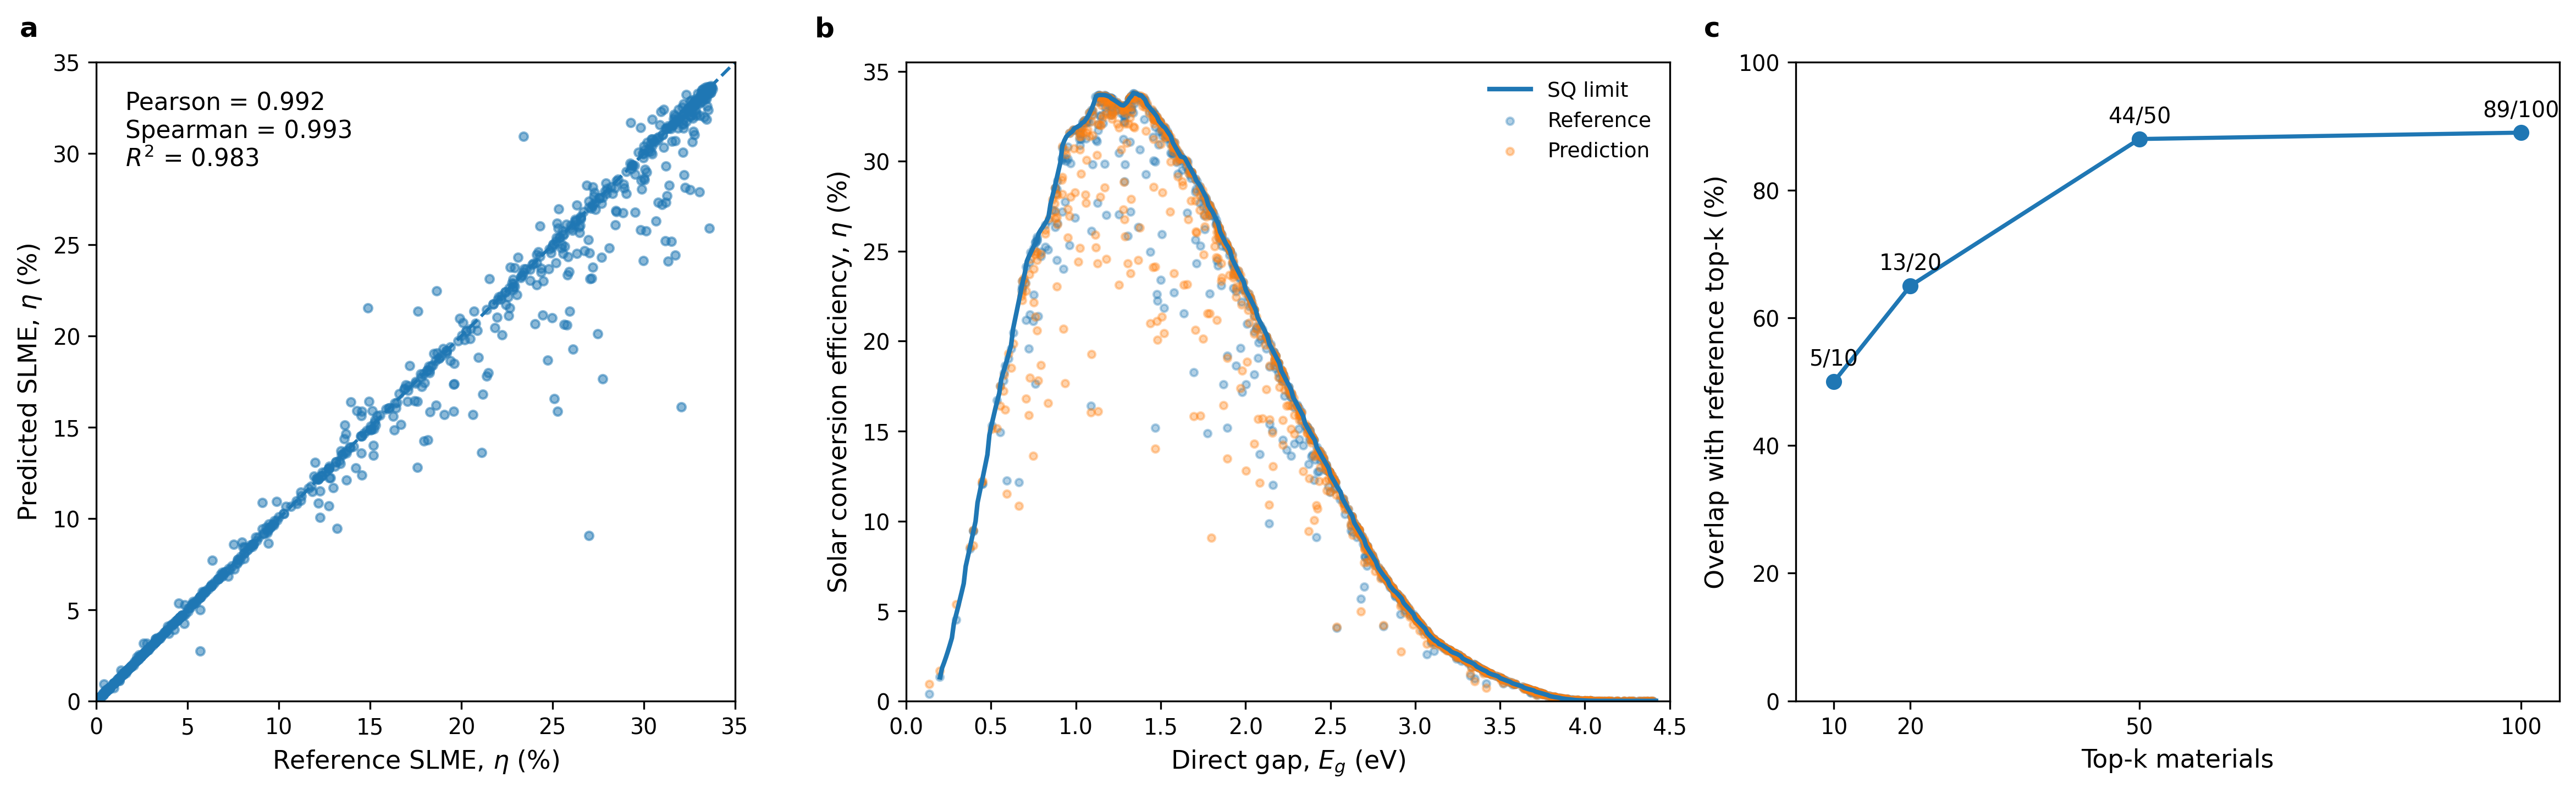


FINAL OUTPUTS
D:\TB3\processed\paired_training\paper_outputs\FINAL_direct_alpha_SLME_500nm\FINAL_direct_alpha_SLME_test_samples.csv
D:\TB3\processed\paired_training\paper_outputs\FINAL_direct_alpha_SLME_500nm\FINAL_direct_alpha_SLME_evaluation.csv
D:\TB3\processed\paired_training\paper_outputs\FINAL_direct_alpha_SLME_500nm\FINAL_SQ_reference_curve.csv
D:\TB3\processed\paired_training\paper_outputs\FINAL_direct_alpha_SLME_500nm\FINAL_direct_alpha_SLME_validation.png
D:\TB3\processed\paired_training\paper_outputs\FINAL_direct_alpha_SLME_500nm\FINAL_direct_alpha_SLME_validation.pdf


In [3]:
# Final held-out Direct-alpha -> SLME validation
# ============================================================

import importlib
import utils_tb.direct_alpha_slme as DAS

DAS = importlib.reload(DAS)

direct_alpha_slme = DAS.run_final_direct_alpha_slme_validation(
    project_root=r"D:\TB3",
    show=True,
)

In [9]:
# FINAL FAIR COMPARISON — run before Route 1/S5 figures and bootstrap
from pathlib import Path
import sys
import importlib

PROJECT_ROOT = Path(r"D:\TB3")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import utils_tb.fair_slme_comparison as FC
FC = importlib.reload(FC)

slme_comparison = FC.run_fair_slme_comparison(
    project_root=PROJECT_ROOT,
)


REFERENCE ALPHA CONSISTENCY
MAE(direct-target reference vs dielectric-derived reference) = 2.042691e-01 cm^-1
Max difference = 2.817246e+00 cm^-1

AM1.5G
Psolar = 994.139932 W/m^2

FIGURE-5 REPRODUCTION CHECK
Reference SLME reproduction MAE = 0.0000000000 pp
Direct SLME reproduction MAE    = 0.0000000000 pp
Existing Figure-5 finite pairs = 853
REPRODUCTION CHECK: PASS

FAIR HEAD-TO-HEAD SAMPLE AUDIT
Held-out total          : 992
Reference finite       : 853
SLME_1 finite          : 853
SLME_2 finite          : 853
COMMON finite samples  : 853

FINAL SLME_1 vs SLME_2 — SAME SAMPLES

                                                Route  n_common       R2  Pearson Spearman   MAE_pp  RMSE_pp Max_predicted_SLME_percent
Route 1: SAE-eps1 + SAE-eps2 -> alpha_derived -> SLME       853 0.982022 0.990997 0.991479 0.591129 1.647034                  33.794386
           Route 2: SAE-alpha -> alpha_direct -> SLME       853 0.982590 0.991814 0.992927 0.592215 1.620791                  33.724535

TO

# Route 2

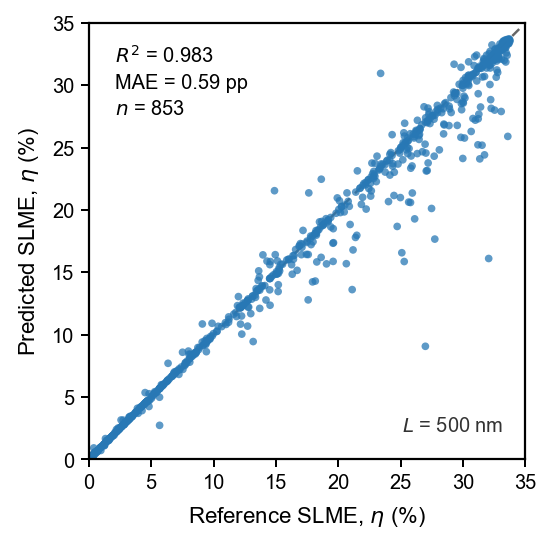

Nguồn: D:\TB3\processed\paired_training\paper_outputs\FINAL_direct_alpha_SLME_500nm\FINAL_direct_alpha_SLME_test_samples.csv
Tổng số mẫu held-out: 992
Cặp SLME hữu hạn dùng cho hình và metrics: 853
Mẫu không đưa vào hình và metrics: 139
R² = 0.982590
MAE = 0.592215 pp | RMSE = 1.620791 pp

Top-k overlap:
  k  overlap_count  overlap_percent
 10              5             50.0
 20             13             65.0
 50             44             88.0
100             89             89.0

Hình đã lưu:
PDF: D:\TB3\processed\paired_training\paper_outputs\FINAL_direct_alpha_SLME_500nm\figure_parity_only_20260930_084858_857097\Heldout_SLME_500nm_parity.pdf
SVG: D:\TB3\processed\paired_training\paper_outputs\FINAL_direct_alpha_SLME_500nm\figure_parity_only_20260930_084858_857097\Heldout_SLME_500nm_parity.svg
PNG: D:\TB3\processed\paired_training\paper_outputs\FINAL_direct_alpha_SLME_500nm\figure_parity_only_20260930_084858_857097\Heldout_SLME_500nm_parity.png
Hình parity duy nhất, khổ 90 x 90 mm; 

In [10]:
# Held-out Direct-alpha SLME — chỉ giữ hình parity (panel a cũ)
from pathlib import Path
import sys
import importlib

PROJECT_ROOT = Path(r"D:\TB3")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import utils_tb.direct_slme_figure as DF
DF = importlib.reload(DF)

direct_figure = DF.plot_direct_slme_parity(
    project_root=PROJECT_ROOT,
    show=True,
)


# Route 1

FINAL HELD-OUT ROUTE-1 SLME
Source CSV:
D:\TB3\processed\paired_training\paper_outputs\FINAL_alpha_route_SLME_comparison_500nm\FINAL_SLME_route1_vs_route2_samples.csv

Rows: 992
Columns:
 - base_idx
 - optical_gap_cutoff_eV
 - reference_SLME_percent
 - route1_derived_alpha_SLME_percent
 - route2_direct_alpha_SLME_percent
 - route1_abs_error_pp
 - route2_abs_error_pp
 - common_valid

Column audit:
 ID        : base_idx
 Reference : reference_SLME_percent
 Route 1   : route1_derived_alpha_SLME_percent
 Validity  : common_valid
 Route 2   : route2_direct_alpha_SLME_percent (present but NOT used)

FROZEN COHORT AUDIT
Held-out total       : 992
common_valid=True    : 853
Finite ref + Route1  : 853
Final evaluation n   : 853
Excluded             : 139

ROUTE-1 HELD-OUT METRICS
R²      = 0.982021959
Pearson = 0.990996768
MAE     = 0.591129206 pp
RMSE    = 1.647034392 pp
Bias    = -0.085525339 pp

Top-k overlap:
  k  overlap_count  overlap_percent
 10              6             60.0
 20       

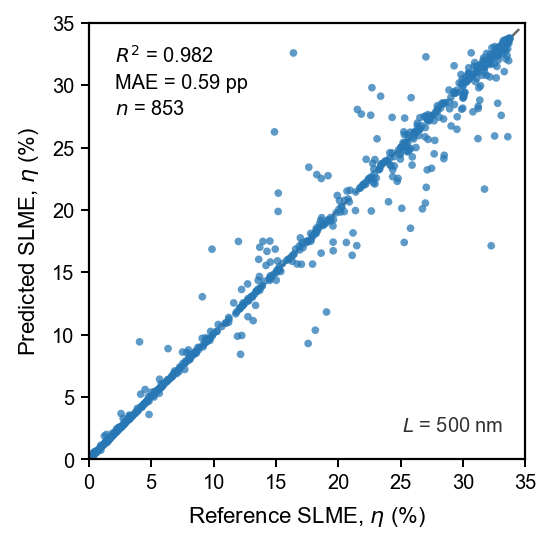


FINAL HELD-OUT ROUTE-1 SLME FIGURE
Route       : SAE-eps1 + SAE-eps2 -> alpha_derived -> SLME
Route1 col  : route1_derived_alpha_SLME_percent
Route2 used : NO
Source      : D:\TB3\processed\paired_training\paper_outputs\FINAL_alpha_route_SLME_comparison_500nm\FINAL_SLME_route1_vs_route2_samples.csv
Total       : 992
Finite      : 853
Excluded    : 139
R²          : 0.982021959
Pearson     : 0.990996768
MAE         : 0.591129206 pp
RMSE        : 1.647034392 pp
Bias        : -0.085525339 pp

Top-k overlap:
  k  overlap_count  overlap_percent
 10              6             60.0
 20             14             70.0
 50             41             82.0
100             88             88.0

Hình đã lưu:
PDF : D:\TB3\processed\paired_training\paper_outputs\FINAL_alpha_route_SLME_comparison_500nm\figure_NC_ROUTE1_20260930_084323_708705\Heldout_ROUTE1_SLME_500nm_parity_topk.pdf
SVG : D:\TB3\processed\paired_training\paper_outputs\FINAL_alpha_route_SLME_comparison_500nm\figure_NC_ROUTE1_20260930_0

In [8]:
# HELD-OUT ROUTE 1 — parity figure and Top-k table
from pathlib import Path
import sys
import importlib

PROJECT_ROOT = Path(r"D:\TB3")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import utils_tb.route1_slme_figure as R1F
R1F = importlib.reload(R1F)

route1_figure = R1F.plot_heldout_route1_slme(
    project_root=PROJECT_ROOT,
    show=True,
)


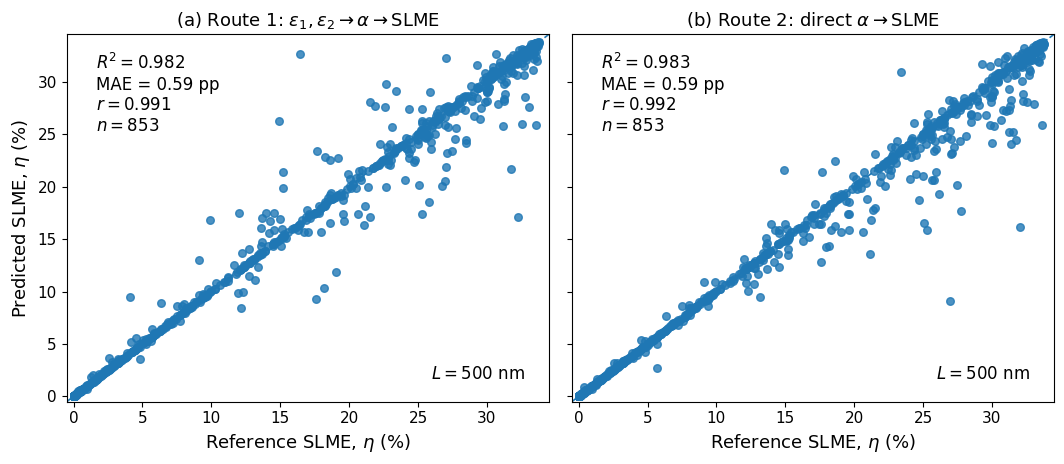

Saved PDF: D:\TB3\figures\S5_route1_vs_route2_SLME.pdf
Saved PNG: D:\TB3\figures\S5_route1_vs_route2_SLME.png

Route 1: R^2=0.982022, MAE=0.591129 pp, r=0.990997, n=853
Route 2: R^2=0.982590, MAE=0.592215 pp, r=0.991814, n=853


In [7]:
# SI S5 — held-out Route 1 vs Route 2
from pathlib import Path
import sys
import importlib

PROJECT_ROOT = Path(r"D:\TB3")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import utils_tb.route_slme_figure as RF
RF = importlib.reload(RF)

route_figure = RF.plot_route_slme_comparison(
    project_root=PROJECT_ROOT,
    output_dir=PROJECT_ROOT / "figures",
    show=True,
)


In [ ]:
# FINAL PAIRED BOOTSTRAP — held-out Route 1 vs Route 2
from pathlib import Path
import sys
import importlib

PROJECT_ROOT = Path(r"D:\TB3")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import utils_tb.paired_bootstrap as PB
PB = importlib.reload(PB)

bootstrap_result = PB.run_paired_slme_bootstrap(
    project_root=PROJECT_ROOT,
    n_boot=20_000,
    seed=2025,
)


ROUTE 2 — DIRECT-alpha DFT40 INPUT AUDIT
Screening CSV : D:\TB3\processed\paired_training\paper_outputs\screening_SLME_direct_alpha_500nm\zintl_external_1100_direct_alpha_SLME_all.csv
Direct α NPZ  : D:\TB3\processed\paired_training\paper_outputs\screening_SLME_direct_alpha_500nm\zintl_external_1100_direct_alpha_SLME_spectra.npz
DFT root      : D:\DFT_TEST\collect_data_epsilon_batch2
Output        : D:\TB3\Section6_DFT40_ROUTE2_20260930_081443_824387
Pool size     : 1100
ML spectra    : (1100, 2001)

DFT .dat files discovered : 40
Unique MP IDs              : 40

Psolar: 994.139932 W/m²

FINAL ROUTE-2 DFT40 AUDIT
DFT spectra                 : 40
Route-2 Top-50 membership   : 38/40
ML SLME > 30%               : 40/40
DFT SLME > 30%              : 40/40
ML–DFT SLME MAE             : 1.111373 pp
ML–DFT SLME RMSE            : 1.479807 pp
ML–DFT SLME mean bias       : +1.108932 pp
DFT SLME range              : 30.1613–33.6639%
ML SLME range               : 33.3866–33.7534%
SI saved: D:\TB3\

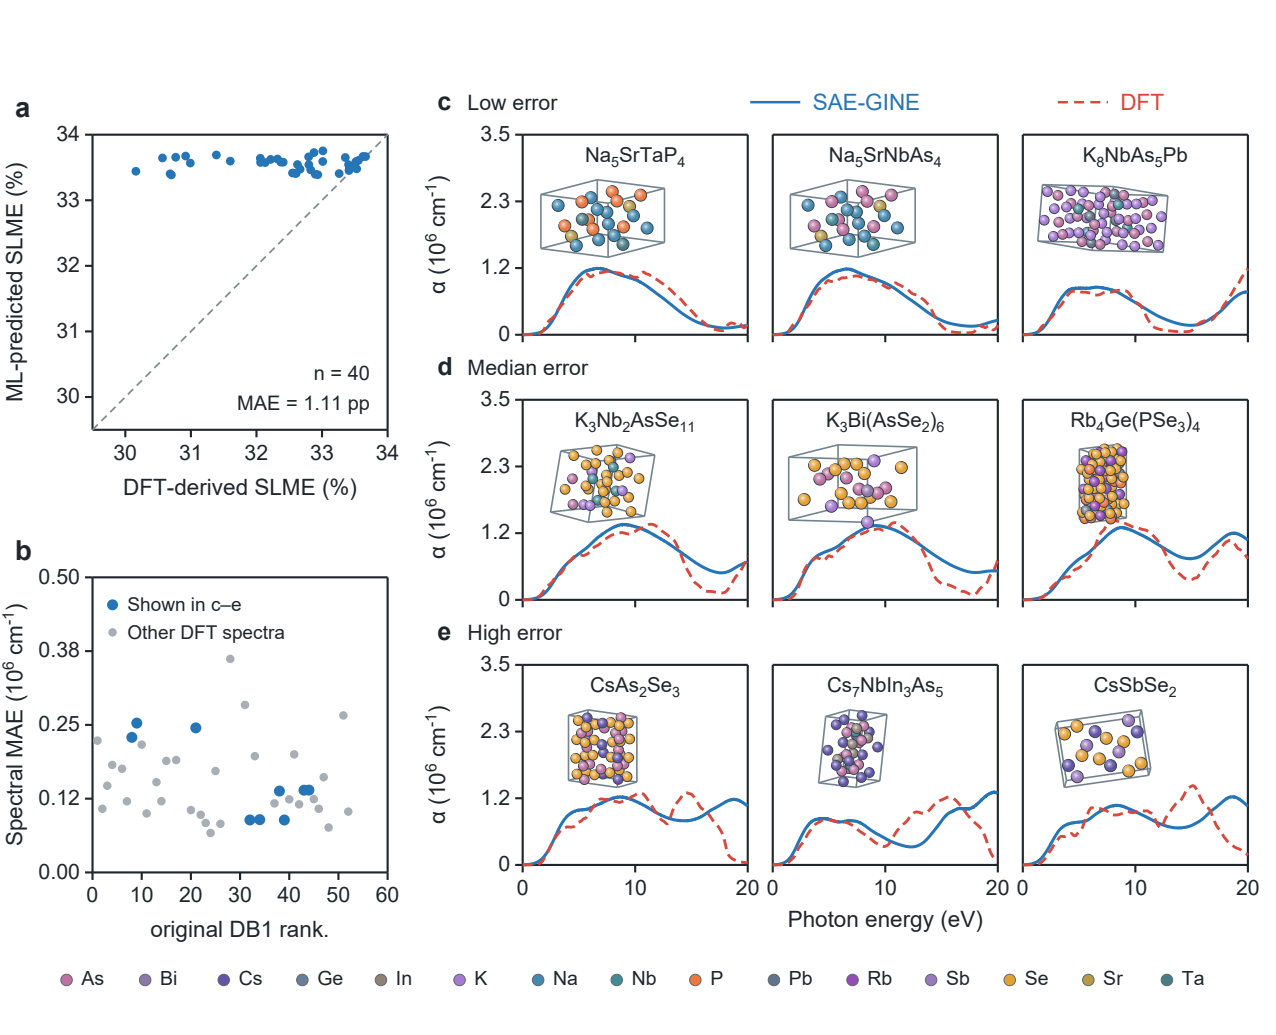


DONE — DFT40 Route 2, 0–20 eV
Thư mục: D:\TB3\Section6_DFT40_ROUTE2_20260930_081443_824387
PDF: D:\TB3\Section6_DFT40_ROUTE2_20260930_081443_824387\Figure6_DFT40_ROUTE2_nine_spectra.pdf
PNG 600 dpi: D:\TB3\Section6_DFT40_ROUTE2_20260930_081443_824387\Figure6_DFT40_ROUTE2_nine_spectra_600dpi.png
Caption: D:\TB3\Section6_DFT40_ROUTE2_20260930_081443_824387\main_caption.tex
Metrics: D:\TB3\Section6_DFT40_ROUTE2_20260930_081443_824387\metrics_DFT40_ROUTE2.json


In [1]:
from pathlib import Path
import sys
import json
import subprocess
from IPython.display import display, Image

script = Path(r"D:\TB3\Figure7_DFT40_ROUTE2_full20eV.py")

if not script.is_file():
    raise FileNotFoundError(f"Không tìm thấy script:\n{script}")

# Lấy đúng thư mục output do script tạo.
# Không giả định dòng stdout đầu tiên là đường dẫn.
runner = """
import json
import runpy
import sys

result = runpy.run_path(sys.argv[1], run_name="__main__")
print("__OUTPUT_DIR__=" + json.dumps(str(result["OUT"])))
"""

result = subprocess.run(
    [sys.executable, "-X", "utf8", "-c", runner, str(script)],
    cwd=str(script.parent),
    capture_output=True,
    text=True,
    encoding="utf-8",
    errors="replace",
)

if result.returncode != 0:
    print(result.stdout)
    print(result.stderr)
    raise RuntimeError(
        "Chạy DFT40 Route 2 chưa thành công. Xem lỗi phía trên."
    )

marker = "__OUTPUT_DIR__="
output_lines = [
    line for line in result.stdout.splitlines()
    if line.startswith(marker)
]

if not output_lines:
    print(result.stdout)
    raise RuntimeError("Không xác định được thư mục kết quả.")

output = Path(json.loads(output_lines[-1][len(marker):]))

# In báo cáo tính toán, bỏ dòng marker nội bộ.
print("\n".join(
    line for line in result.stdout.splitlines()
    if not line.startswith(marker)
))

stem = "Figure6_DFT40_ROUTE2_nine_spectra"
preview = output / f"{stem}_preview_1.png"

if not preview.is_file():
    raise FileNotFoundError(f"Không tìm thấy ảnh preview:\n{preview}")

display(Image(filename=str(preview)))

print("\nDONE — DFT40 Route 2, 0–20 eV")
print("Thư mục:", output)
print("PDF:", output / f"{stem}.pdf")
print("PNG 600 dpi:", output / f"{stem}_600dpi.png")
print("Caption:", output / "main_caption.tex")
print("Metrics:", output / "metrics_DFT40_ROUTE2.json")